# 2.11 实证练习：用真实A股数据回顾本章概念

> 本节通过真实的A股市场数据，将本章讨论的核心概念——总体与样本、分布及其特征、抽样分布与中心极限定理、样本选择偏差——逐一"落地"。所有数据通过 AKShare 获取，读者可直接运行代码复现结果。

## 2.11.1 环境准备与数据获取



In [ ]:

# ============================================================
# 环境准备
# ============================================================
# pip install akshare pandas numpy matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文显示（根据操作系统自行调整字体）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

import akshare as ak
print(f"AKShare version: {ak.__version__}")


AKShare version: 1.18.39


In [ ]:
# ============================================================
# 数据获取：选取 5 只代表性个股的日度行情
# ============================================================
# 选股逻辑：覆盖不同行业、不同市值、不同波动特征
#   贵州茅台 600519 — 消费龙头，低波动
#   宁德时代 300750 — 新能源龙头，高波动
#   工商银行 601398 — 大型银行，低波动
#   中信证券 600030 — 券商龙头，周期性强
#   平安银行 000001 — 股份制银行，中等波动

from pathlib import Path
import time

stocks = {
    '600519': '贵州茅台',
    '300750': '宁德时代',
    '601398': '工商银行',
    '600030': '中信证券',
    '000001': '平安银行',
}

START, END = '20200101', '20260407'
CACHE_DIR = Path('akshare_cache')
CACHE_DIR.mkdir(exist_ok=True)

def fetch_stock(code: str, name: str, retries: int = 5, base_wait: int = 2) -> pd.DataFrame:
    """获取单只股票的日度行情（前复权），返回含日收益率的 DataFrame。"""
    cache_file = CACHE_DIR / f'{code}_{START}_{END}.csv'

    last_error = None
    for attempt in range(1, retries + 1):
        try:
            # ✅ 修正：使用最新 AKShare 股票日频接口（自动识别沪/深/创业板）
            df = ak.stock_zh_a_hist(
                symbol=code,
                period="daily",
                start_date=START,
                end_date=END,
                adjust="qfq"
            )
            if df is None or df.empty:
                raise ValueError(f'{name}（{code}）返回空数据')

            # ✅ 修正：新接口列名是 日期，无需修改
            df['日期'] = pd.to_datetime(df['日期'])
            df = df.set_index('日期').sort_index()
            df['return'] = df['收盘'].pct_change() * 100  # 百分比收益率
            df = df.dropna(subset=['return'])
            df['code'] = code
            df['name'] = name

            df.to_csv(cache_file, encoding='utf-8-sig')
            return df

        except Exception as e:
            last_error = e
            if attempt < retries:
                wait_seconds = base_wait * attempt
                print(f"  第 {attempt} 次获取失败：{e}")
                print(f"  {wait_seconds} 秒后重试...")
                time.sleep(wait_seconds)

    if cache_file.exists():
        print(f"  在线获取失败，改用本地缓存：{cache_file.name}")
        df = pd.read_csv(cache_file, encoding='utf-8-sig')
        df['日期'] = pd.to_datetime(df['日期'])
        df = df.set_index('日期').sort_index()
        df['code'] = code
        df['name'] = name
        return df

    raise ConnectionError(f'{name}（{code}）多次获取失败，请稍后重试。') from last_error

# 逐只获取并合并
frames = {}
failed = []

for code, name in stocks.items():
    print(f"正在获取 {name}（{code}）...")
    try:
        frames[code] = fetch_stock(code, name)
        print(f"  获得 {len(frames[code])} 个交易日数据，"
              f"时间范围：{frames[code].index[0].date()} ~ {frames[code].index[-1].date()}")
    except Exception as e:
        failed.append(f'{name}（{code}）：{e}')
        print(f"  获取失败：{e}")

if failed:
    raise RuntimeError('以下股票数据仍未成功获取：\n' + '\n'.join(failed))

# 合并为面板
panel = pd.concat(frames.values())
panel = panel[['code', 'name', '收盘', 'return']].copy()
print(f"\n合并后总观测数：{len(panel)}")

正在获取 贵州茅台（600519）...
  获得 1514 个交易日数据，时间范围：2020-01-03 ~ 2026-04-07
正在获取 宁德时代（300750）...
  获得 1514 个交易日数据，时间范围：2020-01-03 ~ 2026-04-07
正在获取 工商银行（601398）...
  获得 1514 个交易日数据，时间范围：2020-01-03 ~ 2026-04-07
正在获取 中信证券（600030）...
  获得 1508 个交易日数据，时间范围：2020-01-03 ~ 2026-04-07
正在获取 平安银行（000001）...
  获得 1514 个交易日数据，时间范围：2020-01-03 ~ 2026-04-07

合并后总观测数：7564


In [ ]:
# ============================================================
# 同时获取沪深 300 指数作为"市场总体"的近似
# ============================================================
index_df = ak.stock_zh_index_daily(symbol="sh000300")
index_df['date'] = pd.to_datetime(index_df['date'])
index_df = index_df.set_index('date').sort_index()
index_df = index_df.loc[START:END]
index_df['return'] = index_df['close'].pct_change() * 100
index_df = index_df.dropna(subset=['return'])
print(f"沪深300指数：{len(index_df)} 个交易日")


沪深300指数：1513 个交易日




---

## 2.11.2 分布的直观认识：五只股票收益率长什么样？

> **回顾**：分布同时回答两个问题——"取值在哪里"（location）和"各取值出现的可能性"（frequency/density）。


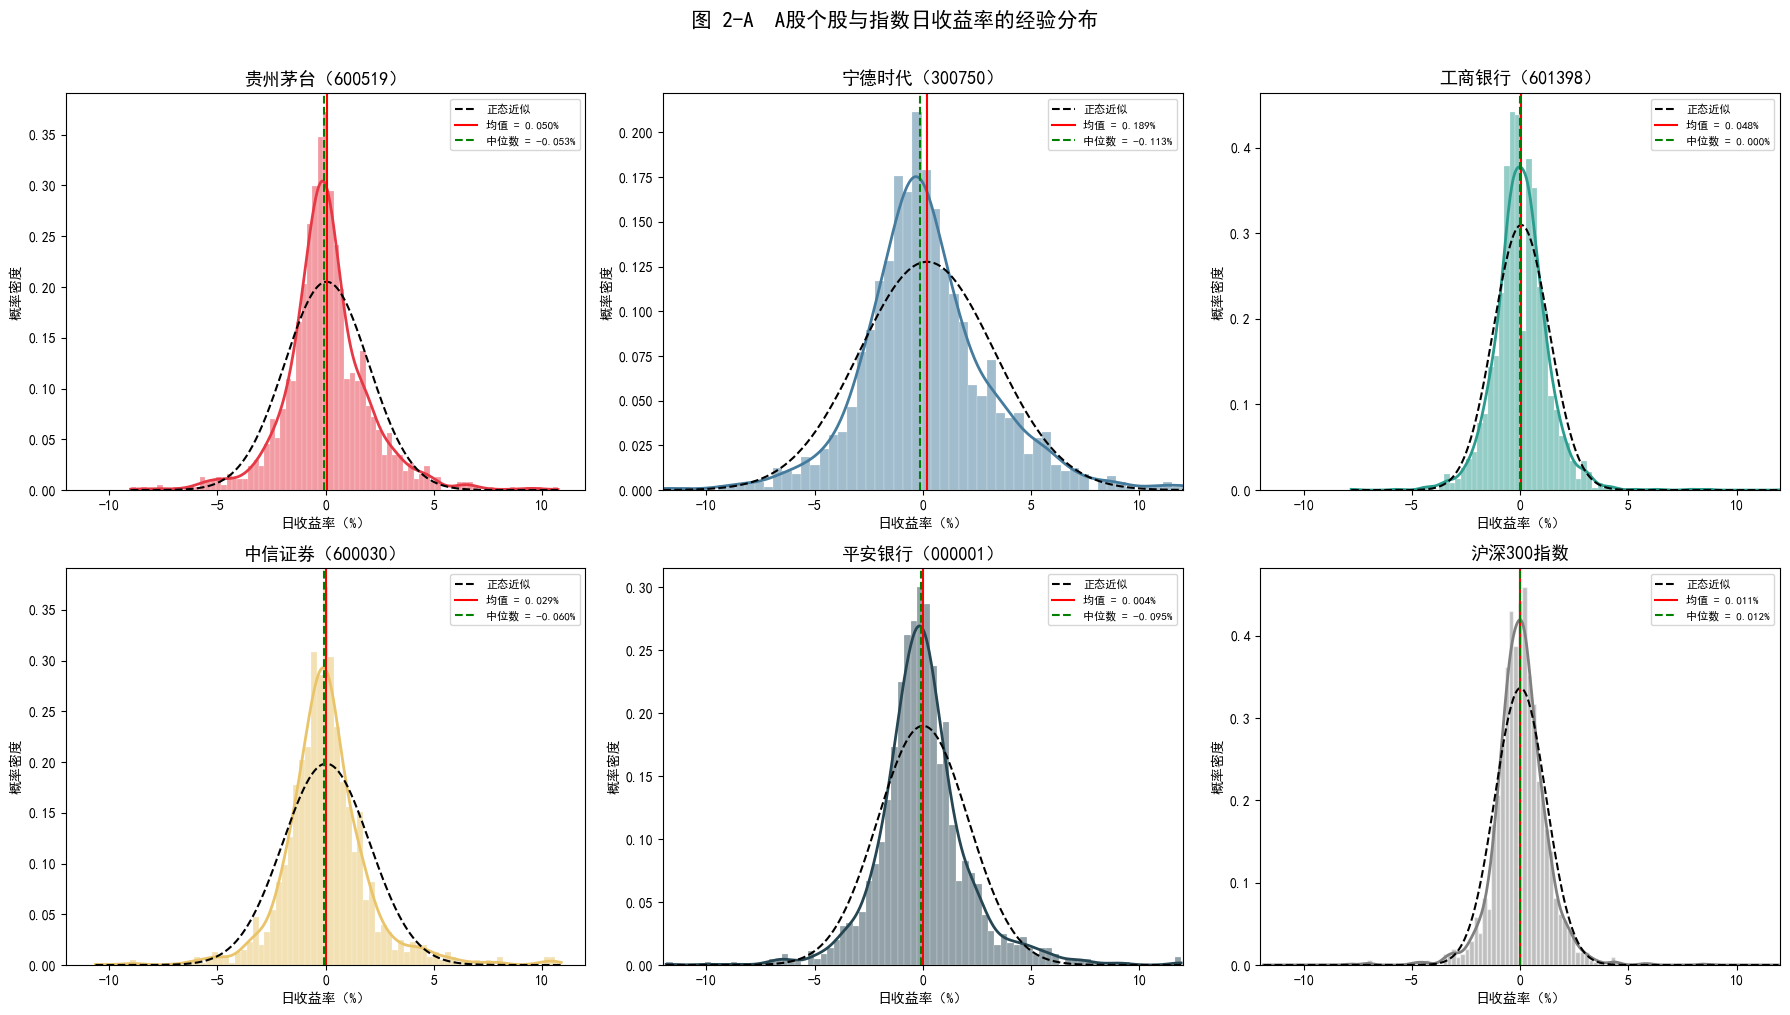

In [ ]:

# ============================================================
# 图 2-A：五只股票日收益率的分布
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#264653']

for idx, (code, name) in enumerate(stocks.items()):
    ax = axes[idx]
    r = frames[code]['return']

    # 直方图 + 核密度估计
    ax.hist(r, bins=80, density=True, alpha=0.5, color=colors[idx],
            edgecolor='white', linewidth=0.3)
    kde_x = np.linspace(r.min(), r.max(), 500)
    kde = stats.gaussian_kde(r)
    ax.plot(kde_x, kde(kde_x), color=colors[idx], linewidth=2)

    # 叠加同均值、同标准差的正态密度曲线
    norm_y = stats.norm.pdf(kde_x, r.mean(), r.std())
    ax.plot(kde_x, norm_y, 'k--', linewidth=1.5, label='正态近似')

    # 标注均值与中位数
    ax.axvline(r.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'均值 = {r.mean():.3f}%')
    ax.axvline(r.median(), color='green', linestyle='--', linewidth=1.5,
               label=f'中位数 = {r.median():.3f}%')

    ax.set_title(f'{name}（{code}）', fontsize=13, fontweight='bold')
    ax.set_xlabel('日收益率（%）')
    ax.set_ylabel('概率密度')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlim(-12, 12)

# 最后一个子图放沪深300
ax = axes[5]
r_idx = index_df['return']
ax.hist(r_idx, bins=80, density=True, alpha=0.5, color='gray', edgecolor='white')
kde_idx = stats.gaussian_kde(r_idx)
ax.plot(kde_x, kde_idx(kde_x), color='gray', linewidth=2)
norm_y_idx = stats.norm.pdf(kde_x, r_idx.mean(), r_idx.std())
ax.plot(kde_x, norm_y_idx, 'k--', linewidth=1.5, label='正态近似')
ax.axvline(r_idx.mean(), color='red', linestyle='-', linewidth=1.5,
           label=f'均值 = {r_idx.mean():.3f}%')
ax.axvline(r_idx.median(), color='green', linestyle='--', linewidth=1.5,
           label=f'中位数 = {r_idx.median():.3f}%')
ax.set_title('沪深300指数', fontsize=13, fontweight='bold')
ax.set_xlabel('日收益率（%）')
ax.set_ylabel('概率密度')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(-12, 12)

plt.suptitle('图 2-A  A股个股与指数日收益率的经验分布',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2a_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



**阅读要点**：
- 每张直方图都是收益率的**经验分布**——它是总体分布的一个近似。
- 黑色虚线是具有相同均值和标准差的正态分布。如果真实分布与正态完全一致，直方图应该与虚线完美重合。
- 注意观察：大部分股票的分布中心比正态更"尖"，尾部比正态更"厚"——这就是 2.4.3 节讨论的**尖峰厚尾**特征。

---

## 2.11.3 描述性统计量：四个数字概括一个分布

> **回顾**：均值（位置）、标准差（离散程度）、偏度（不对称性）、峰度（尾部厚度）。



In [ ]:

# ============================================================
# 表 2-A：描述性统计量汇总
# ============================================================
summary_rows = []
all_series = {**{code: frames[code]['return'] for code in stocks}, 'HS300': index_df['return']}
all_names  = {**stocks, 'HS300': '沪深300'}

for key, r in all_series.items():
    summary_rows.append({
        '股票': all_names[key],
        '代码': key,
        '观测数': len(r),
        '均值(%)': r.mean(),
        '中位数(%)': r.median(),
        '标准差(%)': r.std(ddof=1),
        '最小值(%)': r.min(),
        '最大值(%)': r.max(),
        '偏度': stats.skew(r),
        '超额峰度': stats.kurtosis(r),       # scipy 默认输出超额峰度
        'JB统计量': stats.jarque_bera(r)[0],
        'JB p值': stats.jarque_bera(r)[1],
    })

summary = pd.DataFrame(summary_rows)
# 格式化显示
display_cols = ['股票', '观测数', '均值(%)', '标准差(%)', '偏度', '超额峰度', 'JB p值']
print("=" * 85)
print("表 2-A  A股个股与沪深300指数日收益率的描述性统计")
print("=" * 85)
print(summary[display_cols].to_string(index=False, float_format='%10.4f'))
print("=" * 85)
print("注：JB (Jarque-Bera) 检验的原假设为数据服从正态分布。p值极小表示强烈拒绝正态假设。")


表 2-A  A股个股与沪深300指数日收益率的描述性统计
   股票  观测数  均值(%)  标准差(%)      偏度   超额峰度  JB p值
 贵州茅台 1514 0.0500  1.9450  0.3729 3.6233 0.0000
 宁德时代 1514 0.1887  3.1257  0.6224 3.5180 0.0000
 工商银行 1514 0.0475  1.2885  0.8077 9.3697 0.0000
 中信证券 1508 0.0289  2.0102  0.7596 5.6741 0.0000
 平安银行 1514 0.0043  2.1012  0.5659 4.5800 0.0000
沪深300 1513 0.0115  1.1858 -0.1271 6.0492 0.0000
注：JB (Jarque-Bera) 检验的原假设为数据服从正态分布。p值极小表示强烈拒绝正态假设。


In [7]:
# ============================================================
# 表 2-A：描述性统计量汇总（美观表格版）
# ============================================================
summary_rows = []
all_series = {**{code: frames[code]['return'] for code in stocks}, 'HS300': index_df['return']}
all_names  = {**stocks, 'HS300': '沪深300'}

for key, r in all_series.items():
    summary_rows.append({
        '股票': all_names[key],
        '代码': key,
        '观测数': len(r),
        '均值(%)': r.mean(),
        '中位数(%)': r.median(),
        '标准差(%)': r.std(ddof=1),
        '最小值(%)': r.min(),
        '最大值(%)': r.max(),
        '偏度': stats.skew(r),
        '超额峰度': stats.kurtosis(r),       # scipy 默认输出超额峰度
        'JB统计量': stats.jarque_bera(r)[0],
        'JB p值': stats.jarque_bera(r)[1],
    })

summary = pd.DataFrame(summary_rows)

# 选择要显示的列
display_cols = ['股票', '观测数', '均值(%)', '标准差(%)', '偏度', '超额峰度', 'JB p值']
df_show = summary[display_cols].copy()

# 格式化数字，保证对齐
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.width', 180)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# 输出美观表格
print("\n" + "="*110)
print("表 2-A  A股个股与沪深300指数日收益率的描述性统计".center(110))
print("="*110)
print(df_show.to_string(index=False))
print("="*110)
print("注：JB (Jarque-Bera) 检验的原假设为数据服从正态分布。p值极小表示强烈拒绝正态假设。\n")


                                        表 2-A  A股个股与沪深300指数日收益率的描述性统计                                         
    股票  观测数  均值(%)  标准差(%)    偏度  超额峰度  JB p值
贵州茅台    1514   0.0500     1.9450  0.3729    3.6233  0.0000
宁德时代    1514   0.1887     3.1257  0.6224    3.5180  0.0000
工商银行    1514   0.0475     1.2885  0.8077    9.3697  0.0000
中信证券    1508   0.0289     2.0102  0.7596    5.6741  0.0000
平安银行    1514   0.0043     2.1012  0.5659    4.5800  0.0000
 沪深300    1513   0.0115     1.1858 -0.1271    6.0492  0.0000
注：JB (Jarque-Bera) 检验的原假设为数据服从正态分布。p值极小表示强烈拒绝正态假设。



In [ ]:
import pandas as pd
from IPython.display import display, Markdown

# ============================================================
# 表 2-A：描述性统计量汇总
# ============================================================
summary_rows = []
all_series = {**{code: frames[code]['return'] for code in stocks}, 'HS300': index_df['return']}
all_names  = {**stocks, 'HS300': '沪深300'}

for key, r in all_series.items():
    summary_rows.append({
        '股票': all_names[key],
        '代码': key,
        '观测数': len(r),
        '均值(%)': r.mean(),
        '中位数(%)': r.median(),
        '标准差(%)': r.std(ddof=1),
        '最小值(%)': r.min(),
        '最大值(%)': r.max(),
        '偏度': stats.skew(r),
        '超额峰度': stats.kurtosis(r),       # scipy 默认输出超额峰度
        'JB统计量': stats.jarque_bera(r)[0],
        'JB p值': stats.jarque_bera(r)[1],
    })

summary = pd.DataFrame(summary_rows)

# 仅展示需要的列
display_cols = ['股票', '观测数', '均值(%)', '标准差(%)', '偏度', '超额峰度', 'JB p值']
table_show = summary[display_cols].copy()

# ------------------------------------------------------------
# 使用 pandas Styler 美化表格
# 说明：
# 1. format() 用于统一小数位数
# 2. set_properties() 控制对齐方式
# 3. set_table_styles() 控制表头、边框、标题等样式
# 4. hide(axis='index') 隐藏默认行号
# ------------------------------------------------------------
styled_table = (
    table_show.style
    .format({
        '观测数': '{:,.0f}',
        '均值(%)': '{:.4f}',
        '标准差(%)': '{:.4f}',
        '偏度': '{:.4f}',
        '超额峰度': '{:.4f}',
        'JB p值': '{:.4f}',
    })
    .set_caption('表 2-A  A股个股与沪深300指数日收益率的描述性统计')
    .set_properties(subset=['股票'], **{
        'text-align': 'center'
    })
    .set_properties(subset=['观测数', '均值(%)', '标准差(%)', '偏度', '超额峰度', 'JB p值'], **{
        'text-align': 'right'
    })
    .set_table_styles([
        # 整张表
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('margin', '10px 0'),
            ('font-size', '13px'),
            ('width', '85%')
        ]},
        # 标题
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '8px')
        ]},
        # 表头
        {'selector': 'th', 'props': [
            ('border', '1px solid #999'),
            ('background-color', '#f2f2f2'),
            ('text-align', 'center'),
            ('padding', '6px 10px')
        ]},
        # 数据单元格
        {'selector': 'td', 'props': [
            ('border', '1px solid #ccc'),
            ('padding', '6px 10px')
        ]}
    ])
    .hide(axis='index')
)

# 显示表格
display(styled_table)

# 显示表下注
display(Markdown(
    "注：JB (Jarque-Bera) 检验的原假设为数据服从正态分布。"
    "p 值极小表示强烈拒绝正态假设。"
))

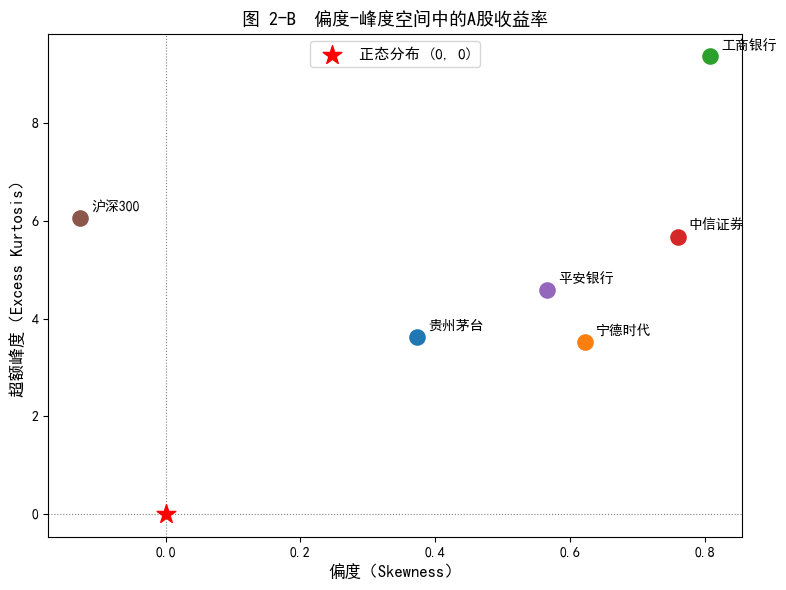

In [8]:

# ============================================================
# 图 2-B：偏度-峰度散点图
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in summary.iterrows():
    ax.scatter(row['偏度'], row['超额峰度'], s=120, zorder=5)
    ax.annotate(row['股票'], (row['偏度'], row['超额峰度']),
                textcoords="offset points", xytext=(8, 5), fontsize=10)

# 标注正态分布的参考点
ax.scatter(0, 0, s=200, marker='*', color='red', zorder=6, label='正态分布 (0, 0)')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('偏度（Skewness）', fontsize=12)
ax.set_ylabel('超额峰度（Excess Kurtosis）', fontsize=12)
ax.set_title('图 2-B  偏度-峰度空间中的A股收益率', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig2b_skew_kurt.png', dpi=150, bbox_inches='tight')
plt.show()


**讨论**：

- 所有股票的超额峰度都显著大于零，确认了**厚尾**现象的普遍性。
- Jarque-Bera 检验的 p 值极小（通常远小于 0.01），意味着我们可以强烈拒绝"收益率服从正态分布"的原假设。
- 这对风险管理的启示是：如果用正态分布来估计 VaR（在险价值），将会系统性地**低估**极端损失的发生概率。



## 2.11.4 QQ 图：正态性的直观诊断

> **回顾**：QQ 图将数据的分位数与理论分布（通常是正态分布）的分位数对比。如果数据服从正态分布，散点应落在 45° 对角线上。



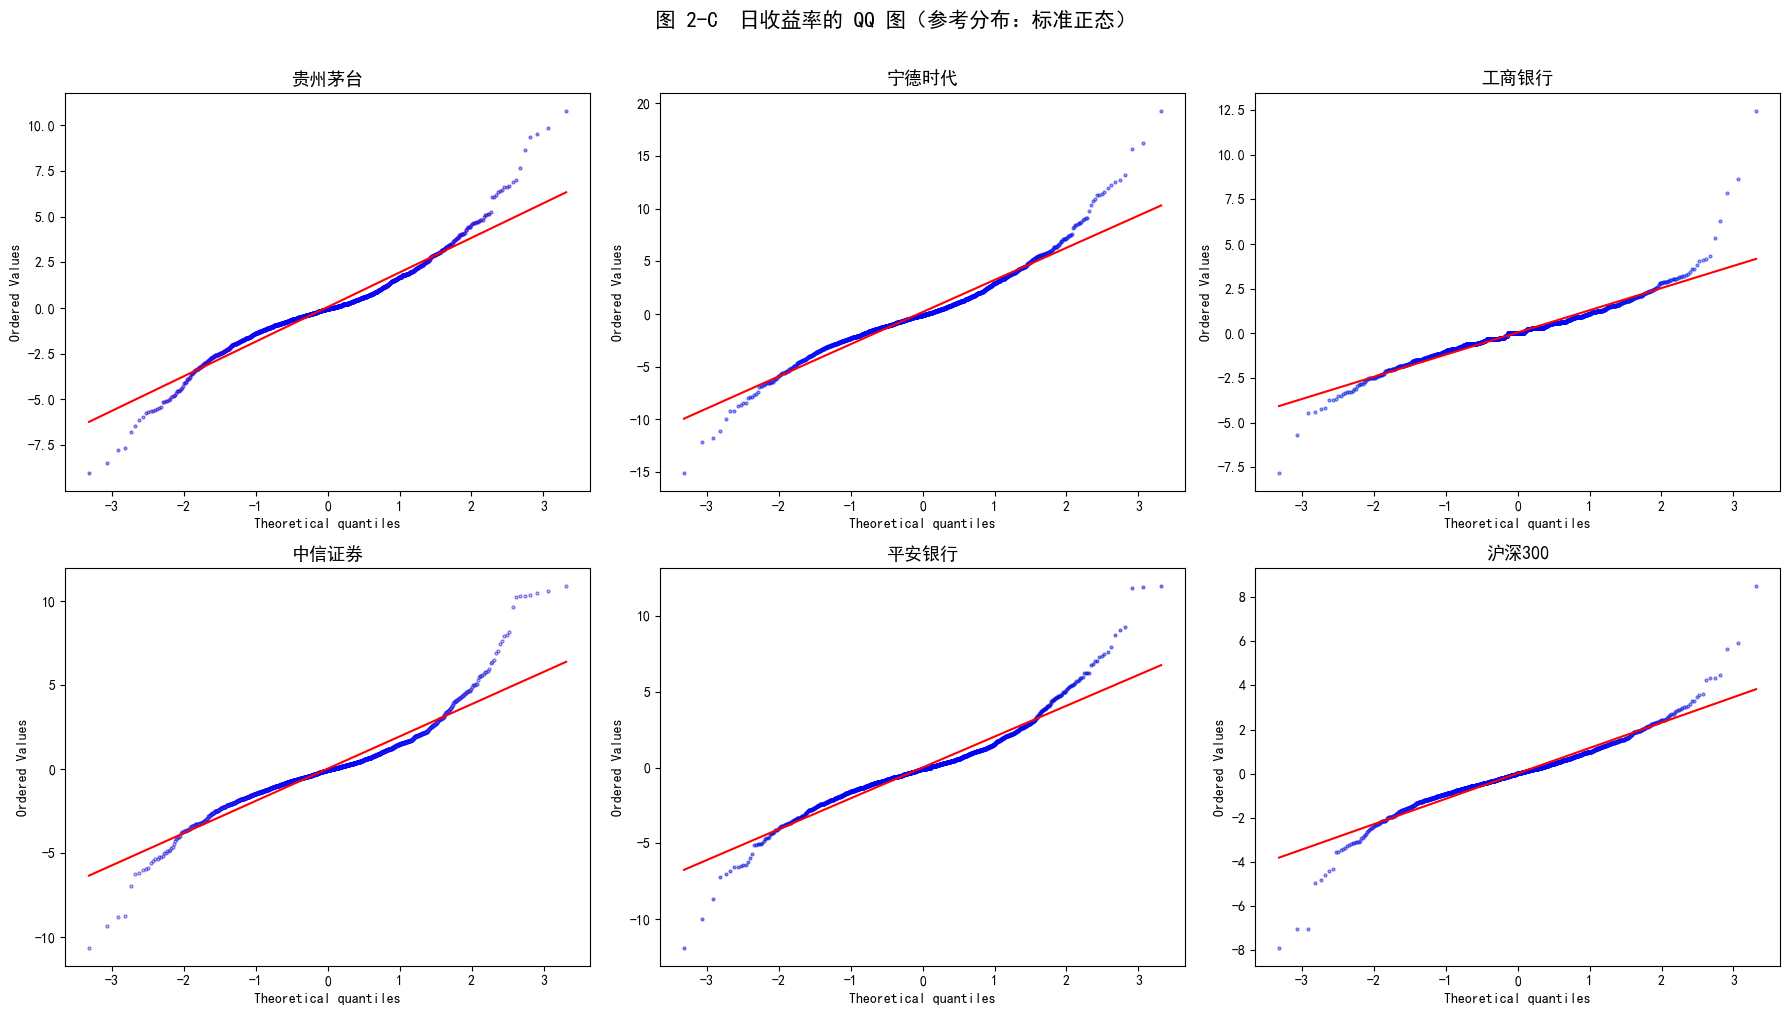

In [ ]:

# ============================================================
# 图 2-C：QQ 图
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for idx, (key, r) in enumerate(all_series.items()):
    ax = axes[idx]
    stats.probplot(r, dist="norm", plot=ax)
    ax.set_title(f'{all_names[key]}', fontsize=13, fontweight='bold')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_markerfacecolor(colors[idx] if idx < 5 else 'gray')
    ax.get_lines()[0].set_alpha(0.5)

plt.suptitle('图 2-C  日收益率的 QQ 图（参考分布：标准正态）',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2c_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()


**阅读要点**：

- 中间部分的点大致落在对角线上——这说明收益率分布的"主体"部分与正态分布相似。
- 两端明显偏离对角线——左下角的点低于对角线、右上角的点高于对角线——说明左尾和右尾都比正态分布更厚，即极端收益（无论涨跌）出现的频率高于正态预期。
- 这与我们在表 2-A 中观察到的正超额峰度完全一致。



## 2.11.5 "买衬衫"问题的A股版本：同一只股票在不同市场环境下的"尺码"

> **回顾**：2.3.4 节的衬衫尺码例子说明了"分布的相对性"——同一个数值在不同参考分布中的位置不同。



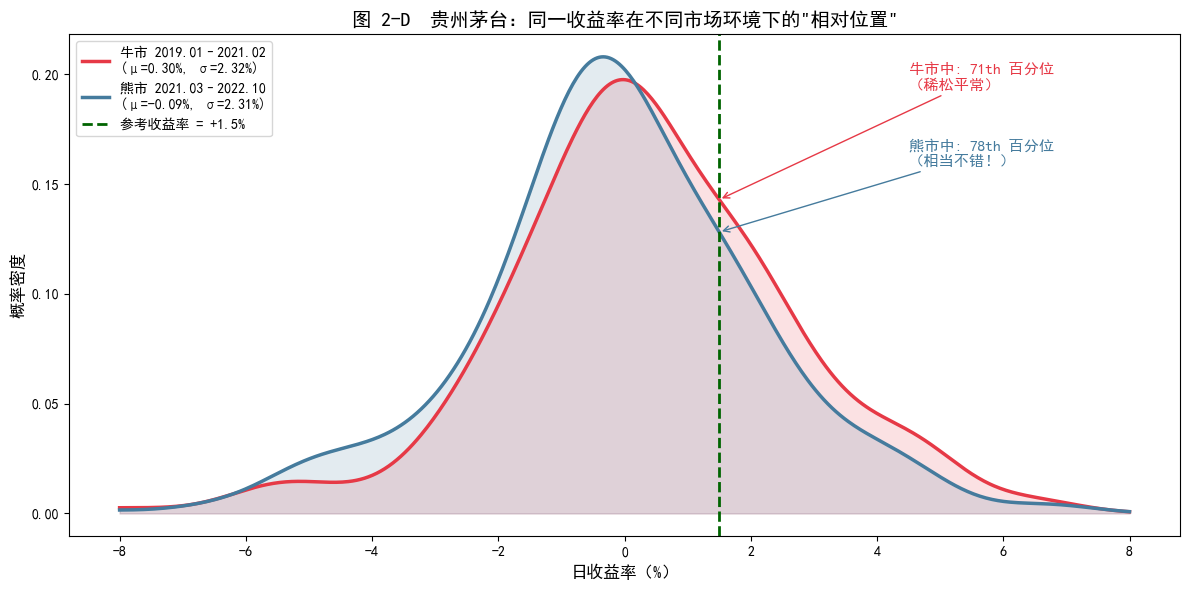

+1.5% 的日收益率：
  牛市中处于第 71.1 百分位 —— 约有 29% 的交易日表现更好
  熊市中处于第 78.3 百分位 —— 仅有 22% 的交易日表现更好


In [10]:

# ============================================================
# 图 2-D：牛市 vs 熊市中，同一日收益率的相对位置
# ============================================================
# 以贵州茅台为例
# 牛市区间：2019-01 ~ 2021-02（茅台从 500 涨到 2600）
# 熊市区间：2021-03 ~ 2022-10（茅台从 2600 跌到 1300 附近）

r_mt = frames['600519']['return']

bull_period = r_mt.loc['2019-01':'2021-02']
bear_period = r_mt.loc['2021-03':'2022-10']

fig, ax = plt.subplots(figsize=(12, 6))

x_range = np.linspace(-8, 8, 500)

# 牛市分布
kde_bull = stats.gaussian_kde(bull_period)
ax.plot(x_range, kde_bull(x_range), color='#E63946', linewidth=2.5,
        label=f'牛市 2019.01–2021.02\n(μ={bull_period.mean():.2f}%, σ={bull_period.std():.2f}%)')
ax.fill_between(x_range, kde_bull(x_range), alpha=0.15, color='#E63946')

# 熊市分布
kde_bear = stats.gaussian_kde(bear_period)
ax.plot(x_range, kde_bear(x_range), color='#457B9D', linewidth=2.5,
        label=f'熊市 2021.03–2022.10\n(μ={bear_period.mean():.2f}%, σ={bear_period.std():.2f}%)')
ax.fill_between(x_range, kde_bear(x_range), alpha=0.15, color='#457B9D')

# 标注一个参考收益率，比如 +1.5%
ref_return = 1.5
ax.axvline(ref_return, color='darkgreen', linestyle='--', linewidth=2,
           label=f'参考收益率 = +{ref_return}%')

# 计算百分位数
bull_pct = stats.percentileofscore(bull_period, ref_return)
bear_pct = stats.percentileofscore(bear_period, ref_return)

ax.annotate(f'牛市中: {bull_pct:.0f}th 百分位\n（稀松平常）',
            xy=(ref_return, kde_bull(ref_return)[0]),
            xytext=(4.5, kde_bull(ref_return)[0] + 0.05),
            fontsize=11, color='#E63946', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E63946'))

ax.annotate(f'熊市中: {bear_pct:.0f}th 百分位\n（相当不错！）',
            xy=(ref_return, kde_bear(ref_return)[0]),
            xytext=(4.5, kde_bear(ref_return)[0] + 0.03),
            fontsize=11, color='#457B9D', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#457B9D'))

ax.set_xlabel('日收益率（%）', fontsize=12)
ax.set_ylabel('概率密度', fontsize=12)
ax.set_title('图 2-D  贵州茅台：同一收益率在不同市场环境下的"相对位置"',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('fig2d_bull_bear.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"+{ref_return}% 的日收益率：")
print(f"  牛市中处于第 {bull_pct:.1f} 百分位 —— 约有 {100-bull_pct:.0f}% 的交易日表现更好")
print(f"  熊市中处于第 {bear_pct:.1f} 百分位 —— 仅有 {100-bear_pct:.0f}% 的交易日表现更好")


**讨论**：

- 同样是 +1.5% 的日收益率，在牛市中可能只是一个中等偏上的表现（"L码"），但在熊市中却是一个非常出色的表现（"XL码"）。
- 这与广州男士在波士顿买衬衫的逻辑完全一致：**一个数值的"含义"取决于它所在的参考分布**。
- 在实际投资中，评估一只基金的业绩好坏，不能只看绝对收益，还要看它在同期市场环境的分布中处于什么位置——这正是"相对排名"和"超额收益"（alpha）的思想基础。





## 2.11.6 中心极限定理的真实数据验证

> **回顾**：2.7.2 节用模拟数据展示了 CLT——无论总体分布形状如何，样本均值的抽样分布在大样本下趋近正态。现在我们用真实数据来验证。



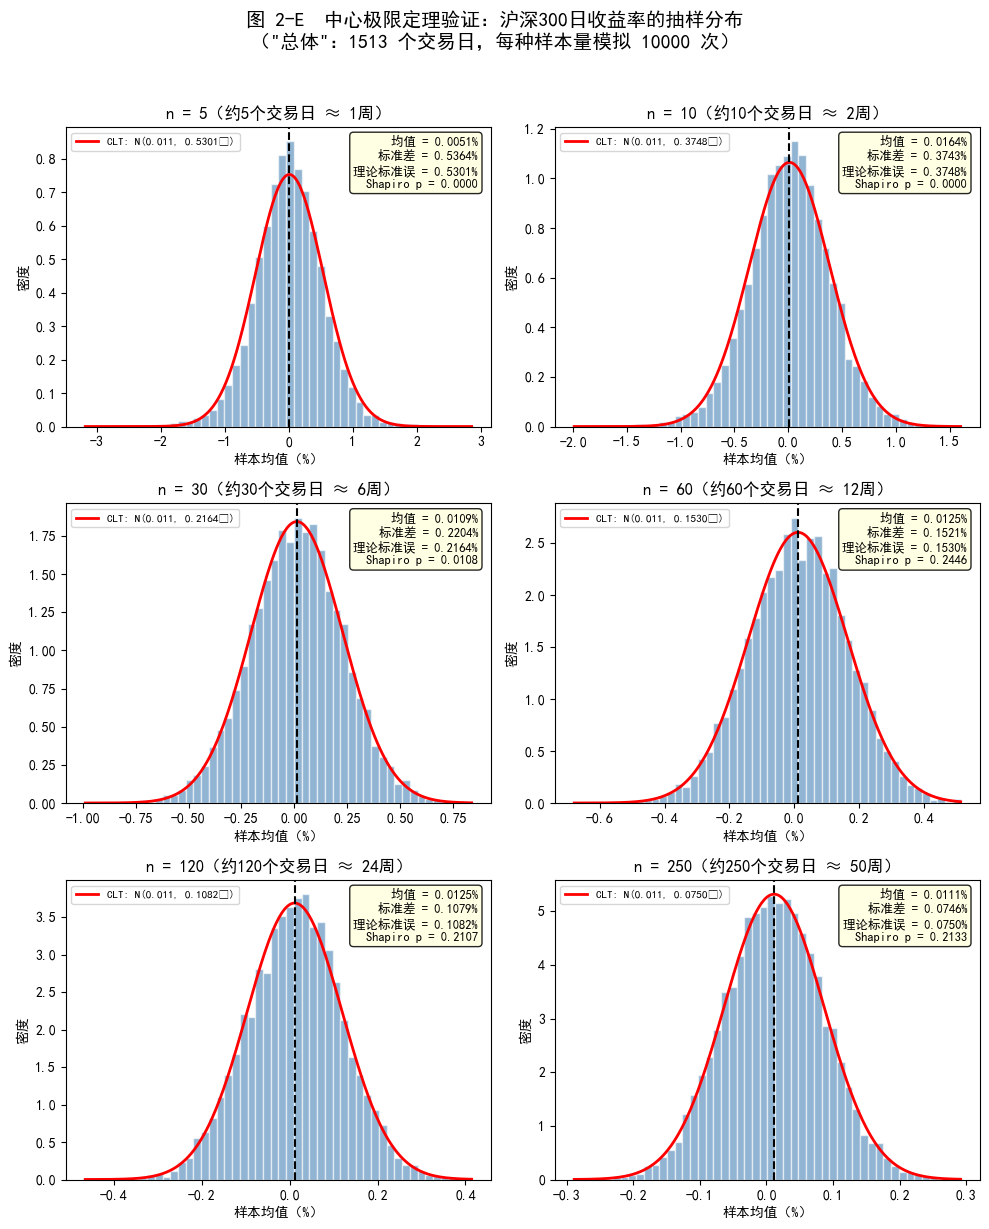

In [ ]:

# ============================================================
# 图 2-E：用真实数据验证中心极限定理
# ============================================================
# 策略：将沪深300的全部日收益率视为"总体"，
#       反复从中抽取不同大小的样本，观察样本均值的分布

r_population = index_df['return'].values
mu_pop = r_population.mean()
sigma_pop = r_population.std()

sample_sizes = [5, 10, 30, 60, 120, 250]
n_simulations = 10000

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes):
    ax = axes[idx]

    # 反复抽样，计算样本均值
    sample_means = np.array([
        np.random.choice(r_population, size=n, replace=True).mean()
        for _ in range(n_simulations)
    ])

    # 直方图
    ax.hist(sample_means, bins=50, density=True, alpha=0.6,
            color='steelblue', edgecolor='white')

    # CLT 正态近似
    x_range = np.linspace(sample_means.min(), sample_means.max(), 300)
    clt_std = sigma_pop / np.sqrt(n)
    clt_pdf = stats.norm.pdf(x_range, mu_pop, clt_std)
    ax.plot(x_range, clt_pdf, 'r-', linewidth=2,
            label=f'CLT: N({mu_pop:.3f}, {clt_std:.4f}²)')

    ax.axvline(mu_pop, color='black', linestyle='--', linewidth=1.5)

    # Shapiro-Wilk 检验（取前 5000 个以满足函数限制）
    _, sw_p = stats.shapiro(sample_means[:5000])

    ax.set_title(f'n = {n}（约{n}个交易日 ≈ {n//5}周）', fontsize=12, fontweight='bold')
    ax.set_xlabel('样本均值（%）')
    ax.set_ylabel('密度')

    textstr = (f'均值 = {sample_means.mean():.4f}%\n'
               f'标准差 = {sample_means.std():.4f}%\n'
               f'理论标准误 = {clt_std:.4f}%\n'
               f'Shapiro p = {sw_p:.4f}')
    props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
    ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('图 2-E  中心极限定理验证：沪深300日收益率的抽样分布\n'
             f'（"总体"：{len(r_population)} 个交易日，每种样本量模拟 {n_simulations} 次）',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2e_clt_real.png', dpi=150, bbox_inches='tight')
plt.show()



**讨论**：

- 即使总体（沪深300日收益率）本身是非正态的（参见前面的 QQ 图），样本均值的分布在 $n \geq 30$ 时就已经非常接近正态分布。
- $n = 250$（约一年的交易日）时，样本均值的标准误（标准差）非常小——这意味着一年的数据已经能给出相当精确的日均收益率估计。
- 但请注意：CLT 保证的是**样本均值**趋近正态，而不是**单个观测值**趋近正态。个股的单日收益率分布仍然是厚尾的。





## 2.11.7 样本选择偏差：存活偏差的真实案例

> **回顾**：2.2.4 节通过鱼塘故事说明了非随机抽样的偏差。这里我们用A股数据展示**存活偏差**——只看"活下来"的股票会如何歪曲我们的推断。



In [16]:

# ============================================================
# 图 2-F：存活偏差演示
# ============================================================
# 思路：比较 "当前沪深300成分股" 在过去的平均表现
#       与 "当时实际的全部A股" 的平均表现
# 沪深300成分股是"幸存者"——它们之所以入选，部分原因是过去表现好

# 获取当前沪深300成分股列表
hs300_stocks = ak.index_stock_cons(symbol="000300")
hs300_codes = set(hs300_stocks['品种代码'].tolist())
print(f"当前沪深300成分股数量：{len(hs300_codes)}")

# 获取一批A股（包括沪深300和非沪深300）的年度收益率
# 为演示方便，我们抽取 200 只非沪深300的股票作为对照
stock_list = ak.stock_zh_a_spot_em()  # 获取全部A股实时行情
all_codes = stock_list['代码'].tolist()
non_hs300_codes = [c for c in all_codes if c not in hs300_codes]

# 随机抽取 150 只非沪深300股票（控制计算量）
np.random.seed(42)
sample_non_hs300 = list(np.random.choice(non_hs300_codes, 150, replace=False))
# 从沪深300中也随机抽取 150 只
sample_hs300 = list(np.random.choice(list(hs300_codes), min(150, len(hs300_codes)), replace=False))

print(f"样本：沪深300成分股 {len(sample_hs300)} 只，非成分股 {len(sample_non_hs300)} 只")


当前沪深300成分股数量：280


  0%|          | 0/58 [00:00<?, ?it/s]

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [ ]:

# 获取两组股票 2020 年全年的收益率
def get_annual_return(code, year='2020'):
    """计算某只股票某一年的累计收益率（%）。"""
    try:
        df = ak.stock_zh_a_hist(
            symbol=code, period="daily",
            start_date=f'{year}0101', end_date=f'{year}1231', adjust="qfq"
        )
        if df is None or len(df) < 20:
            return None
        first_close = df.iloc[0]['收盘']
        last_close = df.iloc[-1]['收盘']
        return (last_close / first_close - 1) * 100
    except Exception:
        return None

print("正在获取沪深300成分股的年度收益率...")
returns_hs300 = {}
for i, code in enumerate(sample_hs300):
    ret = get_annual_return(code, '2020')
    if ret is not None:
        returns_hs300[code] = ret
    if (i + 1) % 30 == 0:
        print(f"  已处理 {i+1}/{len(sample_hs300)}")

print("正在获取非成分股的年度收益率...")
returns_non = {}
for i, code in enumerate(sample_non_hs300):
    ret = get_annual_return(code, '2020')
    if ret is not None:
        returns_non[code] = ret
    if (i + 1) % 30 == 0:
        print(f"  已处理 {i+1}/{len(sample_non_hs300)}")

hs300_rets = np.array(list(returns_hs300.values()))
non_rets = np.array(list(returns_non.values()))
all_rets = np.concatenate([hs300_rets, non_rets])

print(f"\n有效数据：沪深300 {len(hs300_rets)} 只，非沪深300 {len(non_rets)} 只")



# ============================================================
# 绘制图 2-F
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：分布对比 ---
ax = axes[0]
bins = np.linspace(-60, 150, 60)
ax.hist(hs300_rets, bins=bins, density=True, alpha=0.5, color='#E63946',
        label=f'当前沪深300成分股 (n={len(hs300_rets)}, 均值={hs300_rets.mean():.1f}%)')
ax.hist(non_rets, bins=bins, density=True, alpha=0.5, color='#457B9D',
        label=f'非沪深300股票 (n={len(non_rets)}, 均值={non_rets.mean():.1f}%)')
ax.axvline(hs300_rets.mean(), color='#E63946', linestyle='-', linewidth=2)
ax.axvline(non_rets.mean(), color='#457B9D', linestyle='-', linewidth=2)
ax.axvline(all_rets.mean(), color='black', linestyle='--', linewidth=2,
           label=f'全样本均值 = {all_rets.mean():.1f}%')
ax.set_xlabel('2020年累计收益率（%）', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('分布对比', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# --- 右图：箱线图 ---
ax = axes[1]
bp = ax.boxplot([hs300_rets, non_rets, all_rets],
                labels=['沪深300\n成分股', '非沪深300\n股票', '全部\n样本'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#E63946')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('#457B9D')
bp['boxes'][1].set_alpha(0.5)
bp['boxes'][2].set_facecolor('#2A9D8F')
bp['boxes'][2].set_alpha(0.5)
ax.set_ylabel('2020年累计收益率（%）', fontsize=12)
ax.set_title('箱线图对比', fontsize=13, fontweight='bold')

# 在箱线图上标注均值
for i, data in enumerate([hs300_rets, non_rets, all_rets]):
    ax.scatter(i + 1, data.mean(), color='red', s=80, zorder=5, marker='D',
               label='均值' if i == 0 else '')
ax.legend(fontsize=10)

plt.suptitle('图 2-F  存活偏差：用"当前赢家"回看历史表现',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2f_survivorship_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n存活偏差估计：")
print(f"  只看沪深300成分股的平均收益率 = {hs300_rets.mean():.2f}%")
print(f"  非沪深300股票的平均收益率     = {non_rets.mean():.2f}%")
print(f"  全样本的平均收益率             = {all_rets.mean():.2f}%")
print(f"  偏差 = {hs300_rets.mean() - all_rets.mean():.2f} 个百分点")




**讨论**：
- 当前沪深300成分股是根据市值和流动性筛选出来的——它们在一定程度上是过去表现较好的"幸存者"。
- 如果我们只用**当前成分股**来回溯计算"2020年A股的平均收益率"，得到的估计值会**偏高**，因为我们事后排除了那些表现不佳的股票。
- 这与鱼塘故事中"只在中央捞鱼"（策略B）的偏差完全类似——只不过这里的"中央"是"当前的优质公司"。
- **应对策略**：使用**无存活偏差**的数据库（如包含已退市公司的历史数据），或使用当时（point-in-time）的成分股列表进行分析。

---

## 2.11.8 分布在不同语境下的角色：一个综合演示

> **回顾**：2.3.5 节区分了分布的四种角色。这里用贵州茅台的数据做一个综合演示。




# ============================================================
# 图 2-G：分布的不同角色（以贵州茅台为例）
# ============================================================
r_mt = frames['600519']['return'].values

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# ------ 角色一：总体分布（用全样本经验分布近似） ------
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(r_mt, bins=80, density=True, alpha=0.6, color='steelblue', edgecolor='white')
kde = stats.gaussian_kde(r_mt)
x_range = np.linspace(-11, 11, 500)
ax1.plot(x_range, kde(x_range), 'steelblue', linewidth=2)
# 拟合正态分布
mu_fit, sigma_fit = stats.norm.fit(r_mt)
ax1.plot(x_range, stats.norm.pdf(x_range, mu_fit, sigma_fit), 'r--', linewidth=2,
         label=f'拟合正态: N({mu_fit:.3f}, {sigma_fit:.3f}²)')
# 拟合 t 分布
df_fit, loc_fit, scale_fit = stats.t.fit(r_mt)
ax1.plot(x_range, stats.t.pdf(x_range, df_fit, loc_fit, scale_fit), 'g-', linewidth=2,
         label=f'拟合 t 分布: df={df_fit:.1f}')
ax1.set_title('① 总体分布（经验分布 + 参数拟合）', fontsize=12, fontweight='bold')
ax1.set_xlabel('日收益率（%）')
ax1.set_ylabel('密度')
ax1.legend(fontsize=9)

# ------ 角色二：抽样分布 ------
ax2 = fig.add_subplot(gs[0, 1])
n_sizes = [5, 20, 60, 120]
colors_samp = ['#E63946', '#F4A261', '#2A9D8F', '#264653']

for n, color in zip(n_sizes, colors_samp):
    means = np.array([np.random.choice(r_mt, n, replace=True).mean()
                       for _ in range(8000)])
    ax2.hist(means, bins=50, density=True, alpha=0.35, color=color,
             label=f'n={n} (std={means.std():.4f})')

ax2.axvline(r_mt.mean(), color='black', linestyle='--', linewidth=2,
            label=f'总体均值 = {r_mt.mean():.4f}%')
ax2.set_title('② 抽样分布（样本均值的分布）', fontsize=12, fontweight='bold')
ax2.set_xlabel('样本均值（%）')
ax2.set_ylabel('密度')
ax2.legend(fontsize=8)

# ------ 角色三：回归残差的分布（误差项分布） ------
ax3 = fig.add_subplot(gs[1, 0])
# 简单演示：用沪深300收益率解释茅台收益率（CAPM 回归）
# 对齐日期
mt_df = frames['600519'][['return']].rename(columns={'return': 'r_mt'})
idx_df = index_df[['return']].rename(columns={'return': 'r_mkt'})
merged = mt_df.join(idx_df, how='inner').dropna()

from numpy.polynomial.polynomial import polyfit
slope, intercept = np.polyfit(merged['r_mkt'], merged['r_mt'], 1)
merged['predicted'] = intercept + slope * merged['r_mkt']
merged['residual'] = merged['r_mt'] - merged['predicted']

residuals = merged['residual'].values
ax3.hist(residuals, bins=80, density=True, alpha=0.6, color='#E9C46A', edgecolor='white')
kde_res = stats.gaussian_kde(residuals)
x_res = np.linspace(residuals.min(), residuals.max(), 500)
ax3.plot(x_res, kde_res(x_res), color='#E9C46A', linewidth=2)
ax3.plot(x_res, stats.norm.pdf(x_res, residuals.mean(), residuals.std()),
         'r--', linewidth=2, label='正态参考')
ax3.set_title(f'③ 误差项分布（CAPM 回归残差）\n'
              f'r_茅台 = {intercept:.4f} + {slope:.3f} × r_沪深300 + ε',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('残差（%）')
ax3.set_ylabel('密度')

res_skew = stats.skew(residuals)
res_kurt = stats.kurtosis(residuals)
textstr = f'偏度 = {res_skew:.3f}\n超额峰度 = {res_kurt:.3f}'
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
ax3.text(0.97, 0.97, textstr, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)
ax3.legend(fontsize=9)

# ------ 角色四：条件分布 ------
ax4 = fig.add_subplot(gs[1, 1])
# 按市场涨跌分组，看茅台收益率的条件分布
mkt_up = merged.loc[merged['r_mkt'] > 0, 'r_mt']
mkt_down = merged.loc[merged['r_mkt'] <= 0, 'r_mt']

ax4.hist(mkt_up, bins=60, density=True, alpha=0.5, color='#E63946',
         label=f'市场上涨日 (n={len(mkt_up)}, μ={mkt_up.mean():.3f}%)')
ax4.hist(mkt_down, bins=60, density=True, alpha=0.5, color='#457B9D',
         label=f'市场下跌日 (n={len(mkt_down)}, μ={mkt_down.mean():.3f}%)')
ax4.axvline(mkt_up.mean(), color='#E63946', linestyle='-', linewidth=2)
ax4.axvline(mkt_down.mean(), color='#457B9D', linestyle='-', linewidth=2)
ax4.set_title('④ 条件分布（茅台收益率 | 市场涨/跌）', fontsize=12, fontweight='bold')
ax4.set_xlabel('茅台日收益率（%）')
ax4.set_ylabel('密度')
ax4.legend(fontsize=9)

plt.suptitle('图 2-G  分布在统计学中的四种角色（贵州茅台实例）',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('fig2g_four_roles.png', dpi=150, bbox_inches='tight')
plt.show()



**图 2-G 的四个面板分别展示了**：

1. **总体分布**：茅台日收益率的经验分布，以及用正态分布和 $t$ 分布拟合的结果。注意 $t$ 分布（绿色实线）比正态分布（红色虚线）更好地捕捉了厚尾特征——这对后续的 VaR 估计和风险建模有直接意义。

2. **抽样分布**：从总体中反复抽取不同大小的样本，样本均值的分布。样本量越大，抽样分布越窄（精度越高），且越接近正态分布（CLT）。这解释了为什么金融研究中"数据量"如此重要。

3. **误差项分布**：CAPM 回归（$r_{\text{茅台}} = \alpha + \beta \cdot r_{\text{沪深300}} + \varepsilon$）的残差分布。注意残差的超额峰度仍然显著大于零——这意味着标准 OLS 的置信区间和假设检验可能不够精确，可能需要使用稳健标准误（robust standard errors）。

4. **条件分布**：茅台在"市场上涨日"和"市场下跌日"的收益率分布明显不同——不仅均值不同（这正是 $\beta$ 要捕捉的），整个分布的形状和宽度也可能不同。这为后续学习条件异方差模型（如 GARCH）和非线性模型提供了直觉。

---

## 2.11.9 本节小结

通过真实A股数据，我们验证并深化了本章的核心概念：

| 概念 | 模拟数据的结论 | 真实数据的验证 |
|------|--------------|--------------|
| 收益率的非正态性 | 模拟的"混合分布"展现厚尾 | 所有个股和指数的 JB 检验均强烈拒绝正态（图2-A, 表2-A） |
| 超额峰度 > 0 | 设计如此 | 真实数据的超额峰度普遍在 2~10 之间（图2-B） |
| 分布的相对性 | 衬衫尺码类比 | 同一收益率在牛市/熊市中的百分位数截然不同（图2-D） |
| 中心极限定理 | 指数分布总体，$n \geq 30$ 趋近正态 | 真实厚尾总体，$n \geq 30$ 样本均值同样趋近正态（图2-E） |
| 存活偏差 | 鱼塘"岸边捞鱼"低估 | 只看当前沪深300成分股会高估历史平均收益率（图2-F） |
| 分布的多重角色 | 概念区分 | 用茅台 + CAPM 回归同时展示了四种分布角色（图2-G） |

> **给读者的建议**：请动手修改代码中的股票代码、时间区间或样本量参数，观察结果如何变化。统计直觉的建立，离不开对数据的反复把玩和实验。例如：
> - 将贵州茅台换成一只小盘股或ST股票，厚尾特征是更强还是更弱？
> - 将牛市/熊市的时间区间换成其他阶段，"买衬衫"的故事是否仍然成立？
> - 在 CLT 验证中，如果不使用有放回抽样（`replace=True`）而使用无放回抽样，结果会有什么不同？为什么？